# Thử nghiệm siêu tham số (Hyperparameter Tuning)

Notebook này chạy **4 thí nghiệm** theo đúng bảng yêu cầu của đề bài, so sánh kết quả (accuracy, loss) để **chọn ra mô hình tối ưu**.

| Thí nghiệm | Hidden Layers | Learning Rate | Batch Size |
|---|---|---|---|
| 1 | 32-16 | 0.001 | 32 |
| 2 | 64-32 | 0.001 | 32 |
| 3 | 64-32-16 | 0.0001 | 16 |
| 4 | 128-64-32 | 0.001 | 64 |

> **Lưu ý:** số liệu dưới đây chạy trên dữ liệu mẫu. Khi có dữ liệu thật, chỉ cần thay file `data/heart.csv` rồi chạy lại toàn bộ notebook.

## 1. Import và nạp dữ liệu

In [ ]:
import warnings, os, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from model import build_model
from data_loader import load_data

np.random.seed(42)
tf.random.set_seed(42)

X_train, X_test, y_train, y_test = load_data('../data/heart.csv', target_column='target')
input_dim = X_train.shape[1]

I0000 00:00:1781683448.143542    2157 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781683450.415042    2157 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


So dac trung dau vao (input_dim): 13
Kich thuoc tap train: 736 mau
Kich thuoc tap test : 184 mau


## 2. Định nghĩa 4 thí nghiệm

Mỗi thí nghiệm là một bộ (kiến trúc, learning rate, batch size) khác nhau theo bảng đề.

In [ ]:
experiments = [
    {'name': 'Thi nghiem 1', 'hidden': (32, 16),      'lr': 0.001,  'batch': 32},
    {'name': 'Thi nghiem 2', 'hidden': (64, 32),      'lr': 0.001,  'batch': 32},
    {'name': 'Thi nghiem 3', 'hidden': (64, 32, 16),  'lr': 0.0001, 'batch': 16},
    {'name': 'Thi nghiem 4', 'hidden': (128, 64, 32), 'lr': 0.001,  'batch': 64},
]
EPOCHS = 100  # so vong toi da; EarlyStopping se tu dung som

## 3. Chạy lần lượt 4 thí nghiệm

In [ ]:
histories = {}
results = []

for exp in experiments:
    print(f"\n>>> {exp['name']}: hidden={exp['hidden']}, lr={exp['lr']}, batch={exp['batch']}")
    tf.random.set_seed(42)

    model = build_model(input_dim=input_dim,
                        hidden_units=exp['hidden'],
                        learning_rate=exp['lr'])

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True)

    hist = model.fit(X_train, y_train,
                     validation_split=0.2,
                     epochs=EPOCHS, batch_size=exp['batch'],
                     callbacks=[early_stop], verbose=0)
    histories[exp['name']] = hist

    res = dict(zip(model.metrics_names, model.evaluate(X_test, y_test, verbose=0)))
    acc = res.get('compile_metrics', res.get('accuracy'))
    results.append({
        'Thi nghiem': exp['name'],
        'Hidden Layers': '-'.join(map(str, exp['hidden'])),
        'Learning Rate': exp['lr'],
        'Batch Size': exp['batch'],
        'Test Loss': round(res['loss'], 4),
        'Test Accuracy': round(acc, 4),
        'So epoch': len(hist.history['loss']),
    })

print('\nHoan thanh 4 thi nghiem!')


>>> Thi nghiem 1: hidden=(32, 16), lr=0.001, batch=32



>>> Thi nghiem 2: hidden=(64, 32), lr=0.001, batch=32



>>> Thi nghiem 3: hidden=(64, 32, 16), lr=0.0001, batch=16



>>> Thi nghiem 4: hidden=(128, 64, 32), lr=0.001, batch=64



Hoan thanh 4 thi nghiem!


## 4. Bảng so sánh kết quả 4 thí nghiệm

In [ ]:
df = pd.DataFrame(results)
df

,Thi nghiem,Hidden Layers,Learning Rate,Batch Size,Test Loss,Test Accuracy,So epoch
0,Thi nghiem 1,32-16,0.0010,32,0.4661,0.7989,36
1,Thi nghiem 2,64-32,0.0010,32,0.4523,0.7880,21
2,Thi nghiem 3,64-32-16,0.0001,16,0.4474,0.7989,69
3,Thi nghiem 4,128-64-32,0.0010,64,0.4336,0.8207,18


In [ ]:
# Tu dong chon mo hinh tot nhat (accuracy cao nhat; neu bang nhau lay loss thap hon)
best = df.sort_values(['Test Accuracy', 'Test Loss'], ascending=[False, True]).iloc[0]
print('==> Mo hinh tot nhat:')
print(best.to_string())

==> Mo hinh tot nhat:
Thi nghiem       Thi nghiem 4
Hidden Layers       128-64-32
Learning Rate           0.001
Batch Size                 64
Test Loss              0.4336
Test Accuracy          0.8207
So epoch                   18


## 5. Biểu đồ so sánh

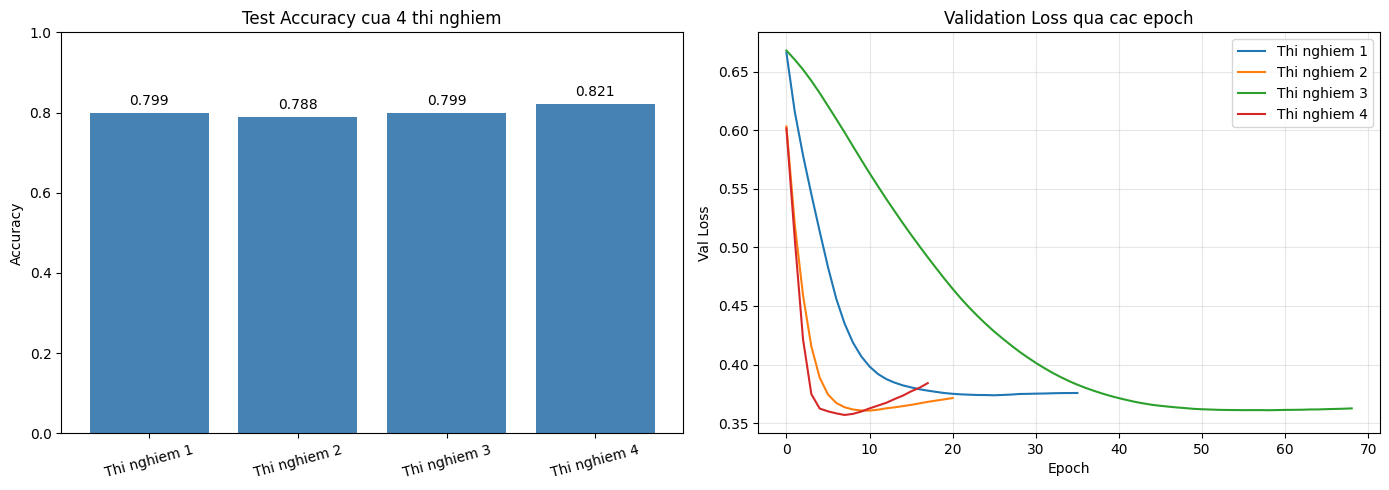

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bieu do cot: accuracy cua 4 thi nghiem
ax1.bar(df['Thi nghiem'], df['Test Accuracy'], color='steelblue')
ax1.set_title('Test Accuracy cua 4 thi nghiem')
ax1.set_ylabel('Accuracy'); ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(df['Test Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Duong validation loss
for name, hist in histories.items():
    ax2.plot(hist.history['val_loss'], label=name)
ax2.set_title('Validation Loss qua cac epoch')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Kết luận

Dựa trên bảng so sánh, chọn mô hình có **accuracy cao nhất** và **loss thấp** làm mô hình cuối cùng cho hệ thống.

_(Viết kết luận cụ thể sau khi chạy với dữ liệu thật — nêu rõ thí nghiệm nào thắng và lý do, ví dụ cân bằng giữa độ chính xác và độ phức tạp mô hình.)_